# NLP practicum
In deze notebook zijn meerdere aanpassingen gedaan met de NLP_practicum_week7.ipynb als basis. Het doel van deze wijzigingen was om de F1-score te verbeteren door zowel de precision als recall te optimaliseren.

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from IPython.display import Markdown, display
import re

In [22]:
# import ahocorasick

### Load terms and concept IDs from MRCONSO

In [23]:
with open("automation.pkl", "rb") as f:
    A = pickle.load(f)

# Functions

In [24]:
def bold_spans(text, spans, color):
    spans = sorted(spans, reverse=True)
    if color==1:
        for start, end in spans:
            text = text[:start] + "<b style=\"color:blue;\">" + text[start:end] + "</b>" + text[end:]
    if color==0:
        for start, end in spans:
            text = text[:start] + "<b style=\"color:red;\">" + text[start:end] + "</b>" + text[end:]
    return text

In [25]:
def visualizeAnnotations(text, annotations,color):
    spans = annotations
    htmlmarkup = bold_spans(text, spans,color)
    md = Markdown(htmlmarkup)
    display(md)

## 1. Correcte berekening van precision en recall

In [26]:
def calculate_precision_recall(annotations, predictions, text=None):
    gold_spans = set(annotations.keys())
    pred_spans = set(predictions)

    TP = len(gold_spans & pred_spans)
    FP = len(pred_spans - gold_spans)
    FN = len(gold_spans - pred_spans)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    # Optional diagnostics: print examples of false positives / false negatives
    if text is not None:
        fp_examples = [(p, text[p[0]:p[1]]) for p in list(pred_spans - gold_spans)[:30]]
        fn_examples = [(p, text[p[0]:p[1]]) for p in list(gold_spans - pred_spans)[:30]]
        print("TP, FP, FN:", TP, FP, FN)
        print("FP examples:", fp_examples)
        print("FN examples:", fn_examples)
    else:
        # if text not given, just print counts
        print("TP, FP, FN:", TP, FP, FN)

    return precision, recall


Set-operaties zorgen voor een exacte en robuuste vergelijking tussen voorspellingen en gold labels. Dit voorkomt dubbele tellingen en logische fouten. Hierdoor wordt de evaluatie betrouwbaarder, wat essentieel is om daadwerkelijk op de juiste metric (F1-score) te optimaliseren.

In [27]:
def f1_score(precision, recall):
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

## 2. generieke worden van spans weghalen

In [28]:
WEAK_EDGE_WORDS = {"human","normal","type","group","patient","patients","cell","cells","gene","genes","protein","proteins"}

def shrink_weak_edges(text, start, end):
    span = text[start:end]
    words = list(re.finditer(r"\b\w+\b", span))
    if len(words) <= 1:
        return start, end
    # trim first
    first = words[0]
    first_word = span[first.start():first.end()].lower()
    if first_word in WEAK_EDGE_WORDS:
        start += first.end()
        while start < end and not text[start].isalnum():
            start += 1
    # recompute and trim last
    span = text[start:end]
    words = list(re.finditer(r"\b\w+\b", span))
    if len(words) <= 1:
        return start, end
    last = words[-1]
    last_word = span[last.start():last.end()].lower()
    if last_word in WEAK_EDGE_WORDS:
        end = start + last.start()
        while end > start and not text[end-1].isalnum():
            end -= 1
    return start, end


Deze functie verwijdert generieke woorden aan de randen van spans, zoals "human", "protein" of "cells". Hierdoor worden spans specifieker en sluiten ze beter aan op de gold standaard. Dit verbetert de precision en soms ook de recall.

## 3. Woordgrens controle

In [ ]:
def is_word_boundary(text, start, end):
    left_ok = start == 0 or not text[start - 1].isalnum()
    right_ok = end == len(text) or not text[end].isalnum()
    return left_ok and right_ok

Deze functie controleert of een match op echte woordgrenzen ligt. Zonder deze controle kunnen delen van woorden onterecht gematcht worden (bijvoorbeeld "cat" in "education"). Dit leidt tot false positives. Door alleen volledige woorden te accepteren, neemt de precision toe.

## 4. Opschonen en valideren van Spans

In [ ]:
def trim_span(text, start, end):
    while start < end and text[start] in "([{\"' ":
        start += 1
    while end > start and text[end - 1] in ")]}\"'.,;: ":
        end -= 1
    return start, end

In [ ]:
def is_valid_span(text, start, end):
    if start >= end:
        return False
    span = text[start:end]
    if re.fullmatch(r"[\W_]+", span):
        return False
    return True

Deze functies zorgen voor het opschonen en valideren van spans. Leestekens en invalide spans (zoals alleen symbolen) worden verwijderd. Dit zorgt ervoor dat voorspellingen beter overeenkomen met de annotaties in de dataset, wat de precision verhoogt.

## 5. enkele woorden checken om ruis te voorkomen

In [ ]:
def looks_like_biomedical_single_word(term):
    # original term, not lowercased
    if any(char.isdigit() for char in term):
        return True
    if "-" in term:
        return True
    if re.search(r"[A-Z].*[A-Z]", term):   # e.g. CFTR, DCTN4, IL6
        return True
    if len(term) >= 5:                     # long technical words
        return True
    return False

In [ ]:
def is_multiword(term):
    return len(term.split()) >= 2   # fix: multiword = 2 or more tokens


Single-word voorspellingen zijn vaak ambigu en veroorzaken false positives. Door alleen woorden toe te laten die kenmerken hebben van biomedische termen (zoals hoofdletters, cijfers of voldoende lengte), wordt ruis verminderd. Dit verhoogt de precision aanzienlijk, met een beperkte impact op recall.

## 7. Spans scores geven

In [29]:
def span_score(text, span):
    start, end = span
    s = text[start:end]
    score = 0
    # multi-word highly preferred
    if len(s.split()) >= 2:
        score += 10
    # length with stronger weight
    score += min(len(s), 50)
    # penalize very short single words
    if len(s.strip()) <= 3 and len(s.split()) == 1:
        score -= 5
    # biomedical-like bonuses
    if any(char.isdigit() for char in s): score += 3
    if "-" in s: score += 2
    if re.search(r"[A-Z].*[A-Z]", s): score += 3
    return score

De scoringfunctie beoordeelt spans op basis van kenmerken zoals lengte, multi-word structuur en biomedische eigenschappen. Dit helpt bij het selecteren van de meest relevante spans, vooral bij overlap. Hierdoor worden minder irrelevante voorspellingen meegenomen, wat de precision verhoogt en indirect ook de F1-score verbetert.

## 7. Overlappende spans oplossen

In [ ]:
def choose_best_overlaps(predictions, text):
    predictions = sorted(predictions, key=lambda x: (x[0], x[1]))
    selected = []

    for span in predictions:
        overlaps = [s for s in selected if not (span[1] <= s[0] or span[0] >= s[1])]

        if not overlaps:
            selected.append(span)
        else:
            candidates = overlaps + [span]
            best = max(candidates, key=lambda x: span_score(text, x))

            for o in overlaps:
                selected.remove(o)

            if best not in selected:
                selected.append(best)

    return selected

Deze functie lost overlappende spans op door slechts de beste te behouden. Zonder deze stap ontstaan dubbele of conflicterende voorspellingen. Door de meest informatieve span te selecteren, wordt ruis verminderd en de kwaliteit van de voorspellingen verhoogd. Dit heeft een sterke positieve invloed op de F1-score.

# Parse Pubtator file 

In [30]:
# Bestand openen en teller initialiseren
file_path = "corpus_pubtator.txt"

lengtes = []
abstracts = []
annotations4abstract =  []

with open(file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

    abstract = ""
    position2cui = {}
    
    for line in lines:

        if '|t|' in line:
            field = line.split('|')[2]
            abstract = field

        if '|a|' in line:
            field = line.split('|')[2]
            abstract += ""+field
            #abstract = abstract.replace('.\n','')
            abstract = abstract.rstrip(".\n")

        if "\t" in line:
            
            start = int(line.split("\t")[1])
            end   = int(line.split("\t")[2])
            woord   = len(line.split("\t")[3])
            position = (start,end)

            lengtes.append(woord)
            
            cui = line.split("\t")[5]
            cui = cui.replace("\n","")
            
            position2cui[position] = cui

        if len(line)==1:
            abstracts.append(abstract)
            abstract = ""

            annotations4abstract.append(position2cui)
            position2cui = {}

In [31]:
index = 0 # Selecteer abstract voor predictie

In [32]:
def predictSpans(text, A):
    predictions = set()
    text_lower = text.lower()

    for end_index, (idx, word) in A.iter(text_lower):
        end = end_index + 1
        start = end - len(word)

        if not is_word_boundary(text_lower, start, end):
            continue

        start, end = trim_span(text, start, end)

        if not is_valid_span(text, start, end):
            continue

        matched_text = text[start:end]

        # MAIN NEW RULE:
        # only keep single-word terms if they look biomedical enough
        if not is_multiword(matched_text):
            if not looks_like_biomedical_single_word(matched_text):
                continue

        predictions.add((start, end))

    predictions = list(predictions)
    predictions = choose_best_overlaps(predictions, text)

    return predictions

`predictions = set()`
Door een set te gebruiken in plaats van een list worden duplicaten automatisch verwijderd. Dit voorkomt dat dezelfde voorspelling meerdere keren wordt meegeteld, wat het aantal false positives verlaagt en de precision verbetert.

`text_lower = text.lower()`
Door case-insensitive matching toe te passen, worden matches gevonden ongeacht hoofdlettergebruik. Dit is belangrijk in biomedische teksten, waar inconsistent hoofdlettergebruik voorkomt. Dit verhoogt de recall.

# Predictions

In [33]:
pred = predictSpans(abstracts[0], A)

In [34]:
print(pred[1:20])

[(31, 63), (67, 82), (83, 105), (111, 120), (124, 139), (145, 153), (157, 172), (173, 178), (179, 188), (189, 206), (219, 227), (233, 240), (244, 253), (263, 278), (279, 300), (331, 340), (376, 384), (416, 423), (424, 433)]


# Validation

In [35]:
annotations = annotations4abstract[index]
calculate_precision_recall(annotations,pred)

TP, FP, FN: 38 57 60


(0.4, 0.3877551020408163)

# Visualisatie

In [36]:
abstract = abstracts[index]
annotations = annotations4abstract[index]
visualizeAnnotations(abstract, annotations.keys(),1)

<b style="color:blue;">DCTN4</b> as a modifier of <b style="color:blue;">chronic Pseudomonas aeruginosa infection</b> in <b style="color:blue;">cystic fibrosis</b>
<b style="color:blue;">Pseudomonas aeruginosa (Pa) infection</b> in <b style="color:blue;">cystic fibrosis</b> (<b style="color:blue;">CF</b>) <b style="color:blue;">patients</b> is associated with worse <b style="color:blue;">long-term</b> <b style="color:blue;">pulmonary disease</b> and <b style="color:blue;">shorter survival</b>, and <b style="color:blue;">chronic Pa infection</b> (<b style="color:blue;">CPA</b>) is associated with <b style="color:blue;">reduced lung function</b>, <b style="color:blue;">faster rate of lung decline</b>, increased <b style="color:blue;">rates</b> of <b style="color:blue;">exacerbations</b> and <b style="color:blue;">shorter survival</b>. By using <b style="color:blue;">exome sequencing</b> and <b style="color:blue;">extreme phenotype design</b>, it was recently shown that <b style="color:blue;">isoforms</b> of <b style="color:blue;">dynactin 4</b> (<b style="color:blue;">DCTN4</b>) may influence <b style="color:blue;">Pa infection</b> in <b style="color:blue;">CF</b>, leading to worse <b style="color:blue;">respiratory disease</b>. The purpose of this <b style="color:blue;">study</b> was to <b style="color:blue;">investigate</b> the role of <b style="color:blue;">DCTN4</b> <b style="color:blue;">missense</b> <b style="color:blue;">variants</b> on <b style="color:blue;">Pa infection</b> <b style="color:blue;">incidence</b>, <b style="color:blue;">age</b> at first <b style="color:blue;">Pa infection</b> and <b style="color:blue;">chronic Pa infection</b> <b style="color:blue;">incidence</b> in a <b style="color:blue;">cohort</b> of <b style="color:blue;">adult</b> <b style="color:blue;">CF</b> <b style="color:blue;">patients</b> from a single <b style="color:blue;">centre</b>. <b style="color:blue;">Polymerase chain reaction</b> and <b style="color:blue;">direct sequencing</b> were used to screen <b style="color:blue;">DNA samples</b> for <b style="color:blue;">DCTN4</b> <b style="color:blue;">variants</b>. A total of 121 <b style="color:blue;">adult</b> <b style="color:blue;">CF</b> <b style="color:blue;">patients</b> from the <b style="color:blue;">Cochin Hospital CF centre</b> have been included, all of them carrying two <b style="color:blue;">CFTR</b> <b style="color:blue;">defects</b>: 103 developed at least 1 <b style="color:blue;">pulmonary infection</b> with <b style="color:blue;">Pa</b>, and 68 <b style="color:blue;">patients</b> of them had <b style="color:blue;">CPA</b>. <b style="color:blue;">DCTN4</b> <b style="color:blue;">variants</b> were identified in 24% (29/121) <b style="color:blue;">CF</b> <b style="color:blue;">patients</b> with <b style="color:blue;">Pa infection</b> and in only 17% (3/18) <b style="color:blue;">CF</b> <b style="color:blue;">patients</b> with no <b style="color:blue;">Pa infection</b>. Of the <b style="color:blue;">patients</b> with <b style="color:blue;">CPA</b>, 29% (20/68) had <b style="color:blue;">DCTN4</b> <b style="color:blue;">missense</b> <b style="color:blue;">variants</b> vs 23% (8/35) in <b style="color:blue;">patients</b> without <b style="color:blue;">CPA</b>. Interestingly, <b style="color:blue;">p.Tyr263Cys</b> tend to be more frequently observed in <b style="color:blue;">CF</b> <b style="color:blue;">patients</b> with <b style="color:blue;">CPA</b> than in <b style="color:blue;">patients</b> without <b style="color:blue;">CPA</b> (4/68 vs 0/35), and <b style="color:blue;">DCTN4</b> <b style="color:blue;">missense</b> <b style="color:blue;">variants</b> tend to be more frequent in <b style="color:blue;">male</b> <b style="color:blue;">CF</b> <b style="color:blue;">patients</b> with <b style="color:blue;">CPA</b> bearing two <b style="color:blue;">class II mutations</b> than in <b style="color:blue;">male</b> <b style="color:blue;">CF</b> <b style="color:blue;">patients</b> without <b style="color:blue;">CPA</b> bearing two <b style="color:blue;">class II mutations</b> (P = 0.06). Our observations reinforce that <b style="color:blue;">DCTN4</b> <b style="color:blue;">missense</b> <b style="color:blue;">variants</b>, especially <b style="color:blue;">p.Tyr263Cys</b>, may be involved in the <b style="color:blue;">pathogenesis</b> of <b style="color:blue;">CPA</b> in <b style="color:blue;">male</b> <b style="color:blue;">CF</b>

In [37]:
visualizeAnnotations(abstract, pred,0)

DCTN4 as a modifier of <b style="color:red;">chronic</b> <b style="color:red;">Pseudomonas aeruginosa infection</b> in <b style="color:red;">cystic fibrosis</b>
<b style="color:red;">Pseudomonas aeruginosa</b> (Pa) <b style="color:red;">infection</b> in <b style="color:red;">cystic fibrosis</b> (CF) <b style="color:red;">patients</b> is <b style="color:red;">associated with</b> <b style="color:red;">worse</b> <b style="color:red;">long-term</b> <b style="color:red;">pulmonary disease</b> and shorter <b style="color:red;">survival</b>, and <b style="color:red;">chronic</b> Pa <b style="color:red;">infection</b> (CPA) is <b style="color:red;">associated with</b> <b style="color:red;">reduced lung function</b>, faster rate of lung decline, <b style="color:red;">increased</b> rates of exacerbations and shorter <b style="color:red;">survival</b>. By using exome sequencing and <b style="color:red;">extreme</b> <b style="color:red;">phenotype</b> design, it was recently shown that <b style="color:red;">isoforms</b> of dynactin 4 (DCTN4) may influence Pa <b style="color:red;">infection</b> in CF, leading to <b style="color:red;">worse</b> <b style="color:red;">respiratory disease</b>. The <b style="color:red;">purpose</b> of this <b style="color:red;">study</b> was to <b style="color:red;">investigate</b> the role of DCTN4 missense <b style="color:red;">variants</b> on Pa <b style="color:red;">infection</b> <b style="color:red;">incidence</b>, age at <b style="color:red;">first</b> Pa <b style="color:red;">infection</b> and <b style="color:red;">chronic</b> Pa <b style="color:red;">infection</b> <b style="color:red;">incidence</b> in a <b style="color:red;">cohort</b> of <b style="color:red;">adult</b> CF <b style="color:red;">patients</b> from a <b style="color:red;">single</b> <b style="color:red;">centre</b>. <b style="color:red;">Polymerase chain reaction</b> and <b style="color:red;">direct</b> sequencing were used to <b style="color:red;">screen</b> DNA samples for DCTN4 <b style="color:red;">variants</b>. A <b style="color:red;">total</b> of 121 <b style="color:red;">adult</b> CF <b style="color:red;">patients</b> from the Cochin <b style="color:red;">Hospital</b> CF <b style="color:red;">centre</b> have been <b style="color:red;">included</b>, all of them <b style="color:red;">carrying</b> two <b style="color:red;">CFTR</b> <b style="color:red;">defects</b>: 103 developed at least 1 <b style="color:red;">pulmonary infection</b> with Pa, and <b style="color:red;">68</b> <b style="color:red;">patients</b> of them had CPA. DCTN4 <b style="color:red;">variants</b> were <b style="color:red;">identified</b> in <b style="color:red;">24</b>% (<b style="color:red;">29</b>/121) CF <b style="color:red;">patients</b> with Pa <b style="color:red;">infection</b> and in only <b style="color:red;">17</b>% (<b style="color:red;">3/18</b>) CF <b style="color:red;">patients</b> with no Pa <b style="color:red;">infection</b>. Of the <b style="color:red;">patients</b> with CPA, <b style="color:red;">29</b>% (<b style="color:red;">20</b>/<b style="color:red;">68</b>) had DCTN4 missense <b style="color:red;">variants</b> vs <b style="color:red;">23</b>% (8/<b style="color:red;">35</b>) in <b style="color:red;">patients</b> <b style="color:red;">without</b> CPA. Interestingly, p.Tyr263Cys tend to be more <b style="color:red;">frequently</b> observed in CF <b style="color:red;">patients</b> with CPA than in <b style="color:red;">patients</b> <b style="color:red;">without</b> CPA (4/<b style="color:red;">68</b> vs 0/<b style="color:red;">35</b>), and DCTN4 missense <b style="color:red;">variants</b> tend to be more <b style="color:red;">frequent</b> in male CF <b style="color:red;">patients</b> with CPA bearing two <b style="color:red;">class II</b> <b style="color:red;">mutations</b> than in male CF <b style="color:red;">patients</b> <b style="color:red;">without</b> CPA bearing two <b style="color:red;">class II</b> <b style="color:red;">mutations</b> (P = <b style="color:red;">0.06</b>). Our <b style="color:red;">observations</b> reinforce that DCTN4 missense <b style="color:red;">variants</b>, especially p.Tyr263Cys, may be <b style="color:red;">involved</b> in the <b style="color:red;">pathogenesis</b> of CPA in male CF

In [38]:
precision = []
recall = []
f1_scores = []
N = len(abstracts)
for k in range(N):
    noot = predictSpans(abstracts[k], A)
    annotations = annotations4abstract[k]
    result = calculate_precision_recall(annotations,noot)
    #print(result)
    precision.append(result[0])
    recall.append(result[1])
    f1_scores.append(f1_score(result[0],result[1]))

TP, FP, FN: 38 57 60
TP, FP, FN: 45 35 35
TP, FP, FN: 29 38 42
TP, FP, FN: 53 32 28
TP, FP, FN: 37 18 42
TP, FP, FN: 35 64 32
TP, FP, FN: 33 43 32
TP, FP, FN: 27 26 41
TP, FP, FN: 29 61 35
TP, FP, FN: 41 44 45
TP, FP, FN: 46 37 46
TP, FP, FN: 77 52 29
TP, FP, FN: 38 28 49
TP, FP, FN: 28 79 26
TP, FP, FN: 39 34 46
TP, FP, FN: 40 23 55
TP, FP, FN: 61 71 36
TP, FP, FN: 70 59 22
TP, FP, FN: 29 15 7
TP, FP, FN: 31 30 57
TP, FP, FN: 50 37 50
TP, FP, FN: 57 28 40
TP, FP, FN: 41 28 48
TP, FP, FN: 47 59 37
TP, FP, FN: 49 49 55
TP, FP, FN: 40 35 27
TP, FP, FN: 28 57 51
TP, FP, FN: 51 43 50
TP, FP, FN: 34 18 31
TP, FP, FN: 64 25 28
TP, FP, FN: 46 26 37
TP, FP, FN: 45 31 50
TP, FP, FN: 47 53 57
TP, FP, FN: 28 38 40
TP, FP, FN: 36 36 30
TP, FP, FN: 38 26 19
TP, FP, FN: 67 66 40
TP, FP, FN: 51 45 25
TP, FP, FN: 36 35 43
TP, FP, FN: 37 53 51
TP, FP, FN: 48 23 27
TP, FP, FN: 53 62 36
TP, FP, FN: 16 27 27
TP, FP, FN: 46 52 78
TP, FP, FN: 56 24 54
TP, FP, FN: 46 53 34
TP, FP, FN: 24 67 33
TP, FP, FN: 50

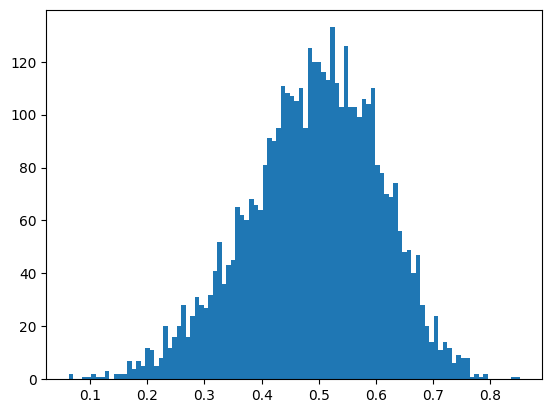

In [39]:
plt.hist(f1_scores,bins=100)
plt.show()

In [40]:
np.mean(f1_scores)

np.float64(0.49071337521264635)

# Conclusie

De verbeteringen zijn voornamelijk gericht op het verhogen van de precision door ruis en onjuiste voorspellingen te verminderen, bijvoorbeeld via filtering op woordgrenzen, het opschonen van spans en het beperken van zwakke single-word matches. Tegelijkertijd blijft de recall behouden of wordt deze licht verbeterd door technieken zoals case-insensitive matching.

Daarnaast zorgen functies zoals choose_best_overlaps en span_score ervoor dat bij meerdere mogelijke voorspellingen de meest relevante wordt geselecteerd. Dit leidt tot minder conflicterende en kwalitatief betere outputs.

Door deze combinatie van gerichte filtering en slimmere selectie ontstaat een betere balans tussen precision en recall, wat uiteindelijk in een verbetering van de F1-score geeft.